In [6]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
plt.rcParams.update({
    "font.family": "serif",    # Use a serif font (like LaTeX default)
})
import scipy as sp
from copy import deepcopy 
from tqdm import tqdm
import os
import sys
sys.path.append(os.path.abspath(".."))

from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix, AET1SensitivityMatrix, LISASens
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State

# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
gpu = False
if gpu:
    import cupy as cp
else:
    import numpy as cp

# Noise Plot

In [2]:
# Tobs is the obvesrvation time in seconds. YRSID_SI is a siderial year = 31558149.763545603 seconds
Tobs = YRSID_SI / 2.

# This is the sampling interval, i.e., the time between two samples. The sampling rate is 1/dt
dt = 5.  # sec

# N is the number of samples in your original time-domain signal.
N = int(int(Tobs / dt)/2)*2

# Convert Tobs into an integer number.
Tobs = N * dt

# This function returns the array of sample frequencies corresponding to the positive frequencies of the real-input Fast Fourier Transform (rFFT)
# The list goes from from zero to the Nyquist frequency, which is half the sampling rate: f[-1] = df/2 = 1/(2*dt)
# len(f) = floor(N/2) + 1 because the Nyquist frequency is included and the negative frequencies are not included in the rFFT
freq = np.fft.rfftfreq(N,dt)

# f[0] is 0.0. To avoid this, set f[0] to f[1]
freq[0] = freq[1]

# stochastic_params in sens_kwargs takes the time to add galactic foreground noise. It makes sense to put it as Tobs, which is the duration of observation.
# This is why N was calculated using Tobs and not written explicitly.
sens_kwargs = dict(stochastic_params=(Tobs,))

# Put the LISA sensitivity model in a list. See lisatools.sensitivity.get_stock_sensitivity_options for the list of available models.
# Does not work for FlatPSDFunction and it's slightly higher than the model for LISASens and CornishLISASens at low frequencies.
plot_labels = ['A', 'E', 'T']

# SensitivityMatrix class gives a model of the LISA instrumental noises, given a frequency array, for every TDI channel in sens_model_array
sens_mat = AET1SensitivityMatrix(freq)

noises = noise_generation.generate_noise(N, dt, sens_mat, seed = 42, verification_plot=False, time_domain_plot=False, plot_lables=plot_labels)

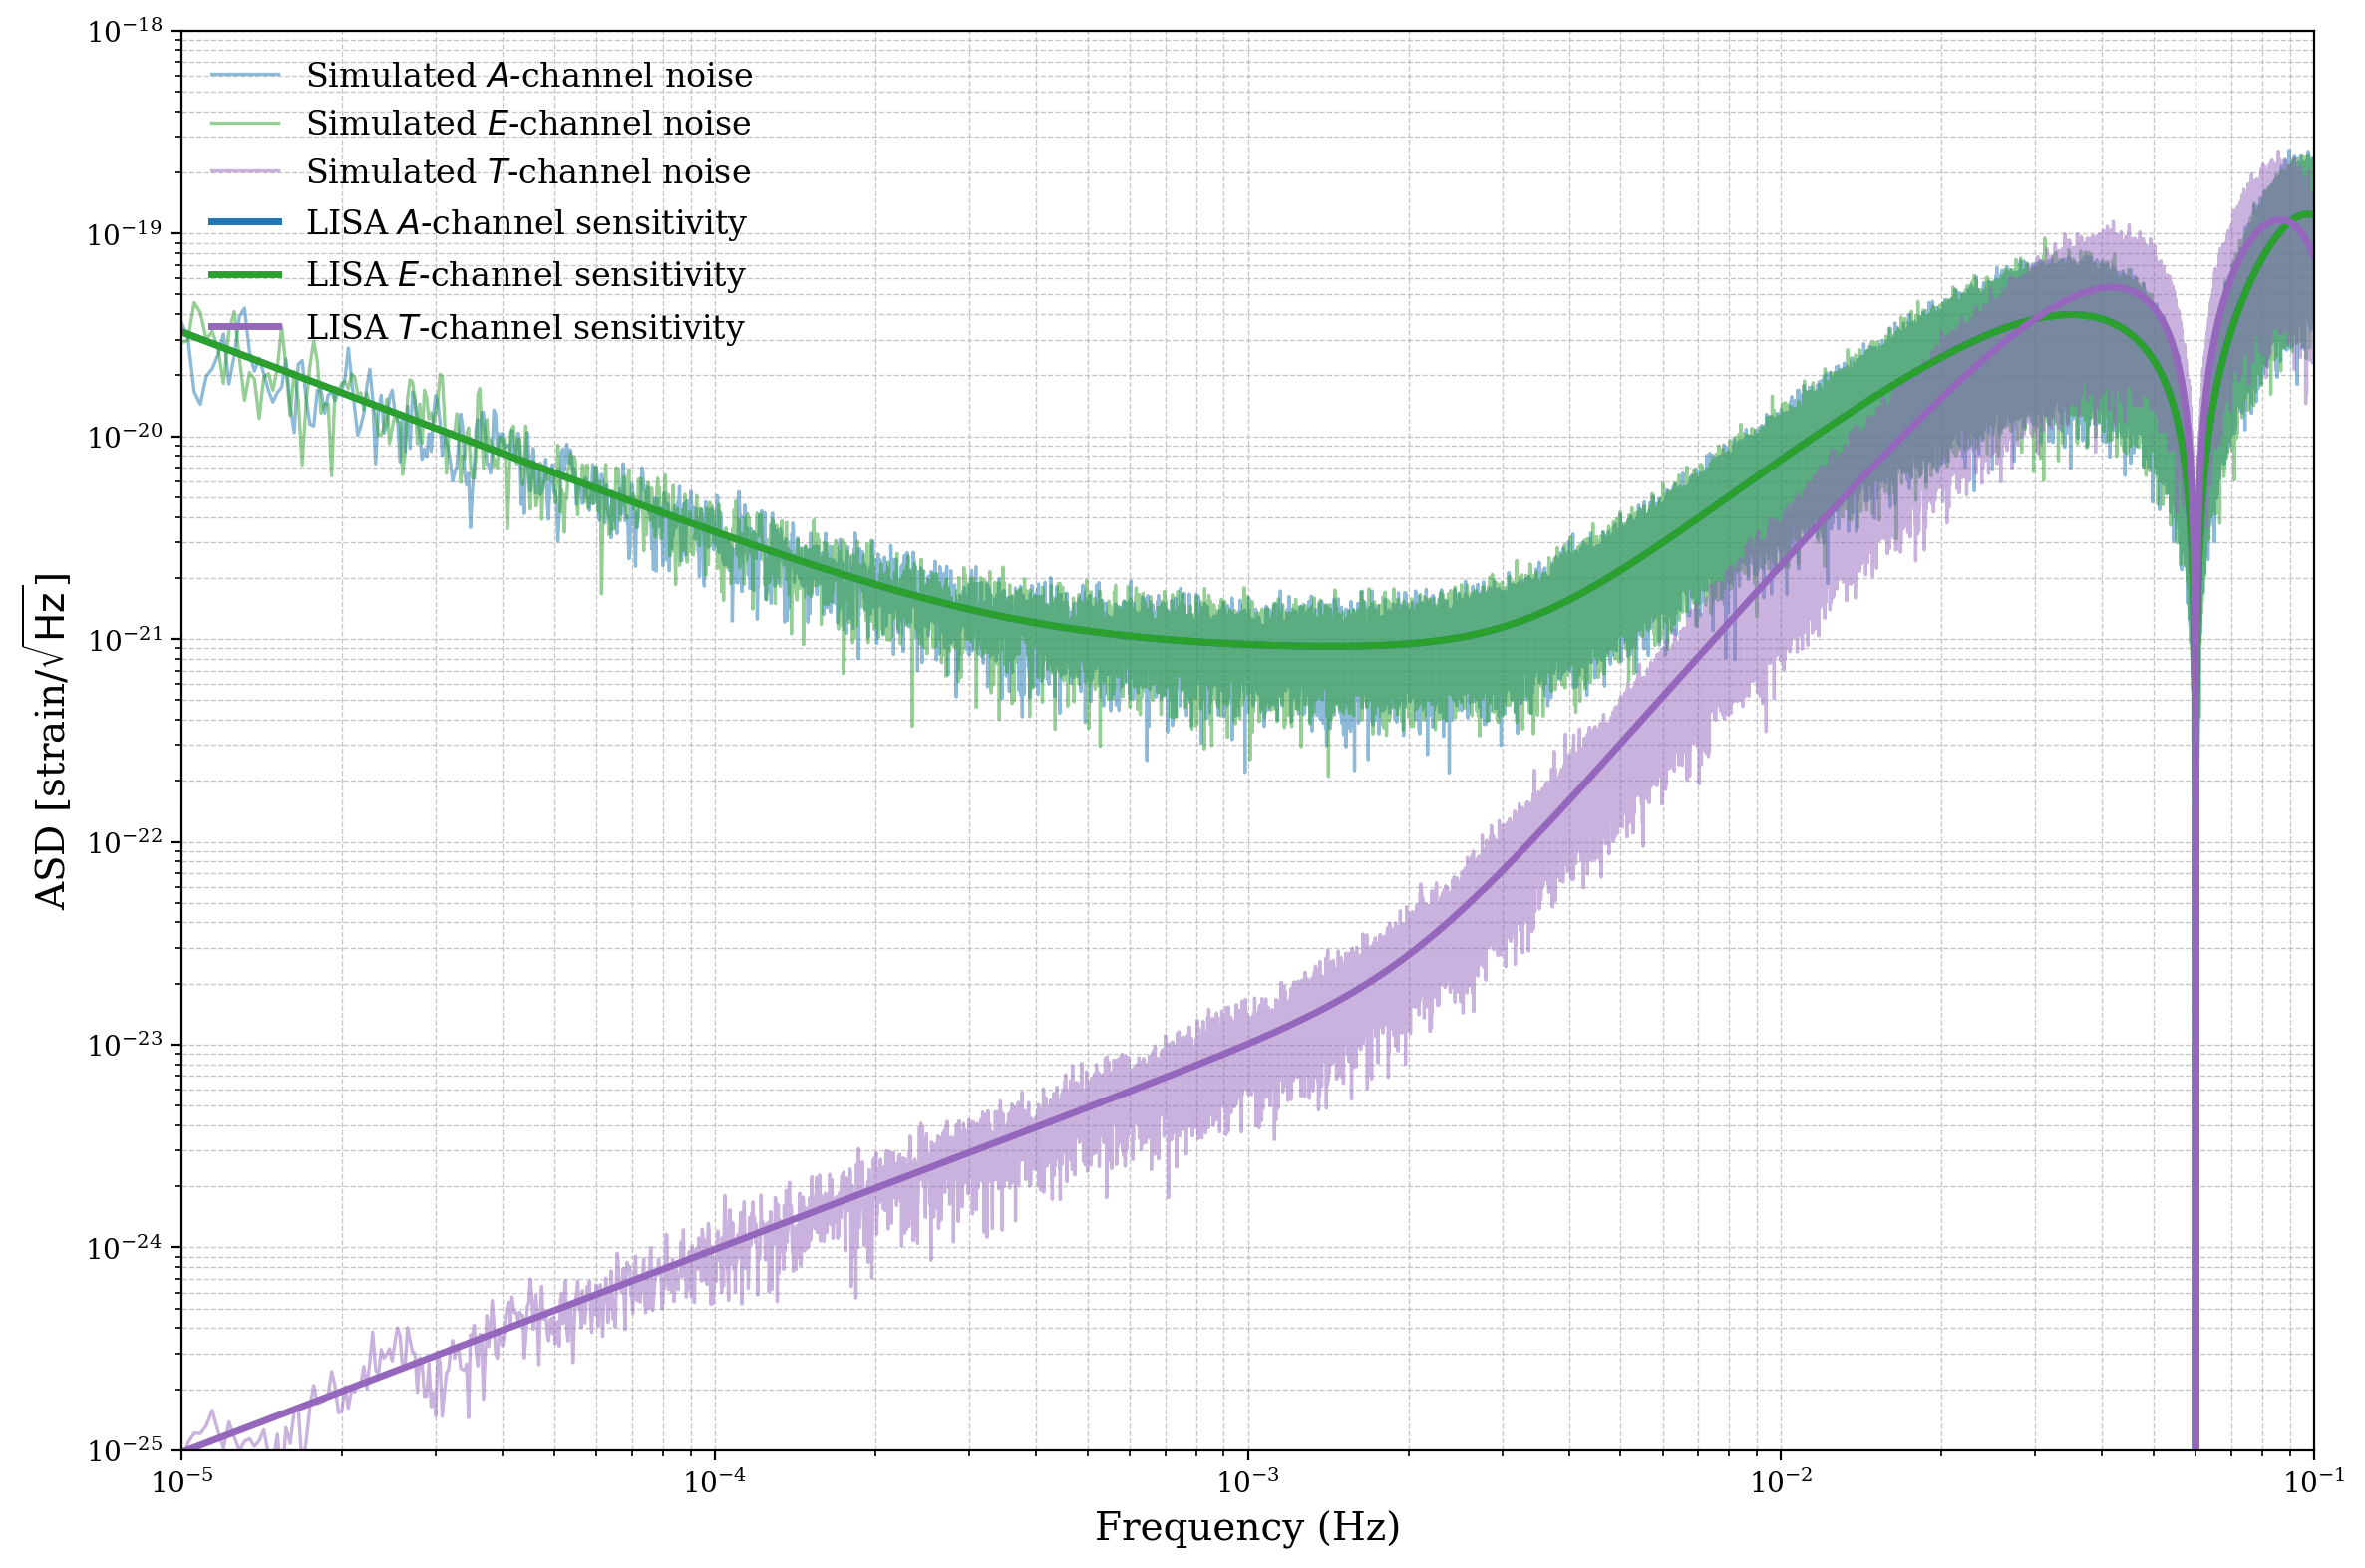

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fout, pxxout = noise_generation.noise_time_to_freq_domain(noises, dt)

plt.figure(figsize=(12, 8))

# Define colors manually (nice, distinguishable palette)
colors = {
    "A": "#1f77b4",  # blue
    "E": "#2ca02c",  # green
    "T": "#9467bd"   # purple
}

# Plot Noise (faded, thinner lines)
plt.loglog(fout[0], np.sqrt(pxxout[0]), label='Simulated $A$-channel noise',
           color=colors["A"], alpha=0.5, lw=1.2)
plt.loglog(fout[1], np.sqrt(pxxout[1]), label='Simulated $E$-channel noise',
           color=colors["E"], alpha=0.5, lw=1.2)
plt.loglog(fout[2], np.sqrt(pxxout[2]), label='Simulated $T$-channel noise',
           color=colors["T"], alpha=0.5, lw=1.2)

# Plot Models (bold, solid lines)
plt.loglog(sens_mat.frequency_arr, np.sqrt(sens_mat.sens_mat[0]),
           label='LISA $A$-channel sensitivity', color=colors["A"], lw=2.5)
plt.loglog(sens_mat.frequency_arr, np.sqrt(sens_mat.sens_mat[1]),
           label='LISA $E$-channel sensitivity', color=colors["E"], lw=2.5)
plt.loglog(sens_mat.frequency_arr, np.sqrt(sens_mat.sens_mat[2]),
           label='LISA $T$-channel sensitivity', color=colors["T"], lw=2.5)

# Labels, limits, and formatting
plt.xlabel(r'Frequency (Hz)', fontsize=14)
plt.ylabel(r'ASD [strain$/\sqrt{\mathrm{Hz}}$]', fontsize=14)

plt.xlim(1e-5, 1e-1)
plt.ylim(1e-25, 1e-18)

plt.grid(True, which='both', ls='--', lw=0.5, alpha=0.7)

plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("thesis_figures/noise_and_sensitivity.pdf", bbox_inches="tight")
plt.show()

In [ ]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 8e5 # 1e5
m2 = 2e5 # 1e5
# chi1z and chi2z are the dimensionless spins of the two black holes assumed to be aligned with the orbital angular momentum.
chi1z = 0.5
chi2z = 0.7
dist = 200 * 1e9 * PC_SI # lower distance try this 
phi_ref = 0.0
f_ref = 0.0
inc = np.pi/3.
beta = np.pi/2. # ecliptic latitude
lam = np.pi  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = Tobs/2  #- 60*60*24  # t_ref  (in the SSB reference frame) = merger time.

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)
wave_time_domain_with_noise = wave_time_domain + noises
fout_withnoise, pxxout_withnoise = noise_generation.noise_time_to_freq_domain(wave_time_domain_with_noise, dt, winow_length_denominotor=4.5)

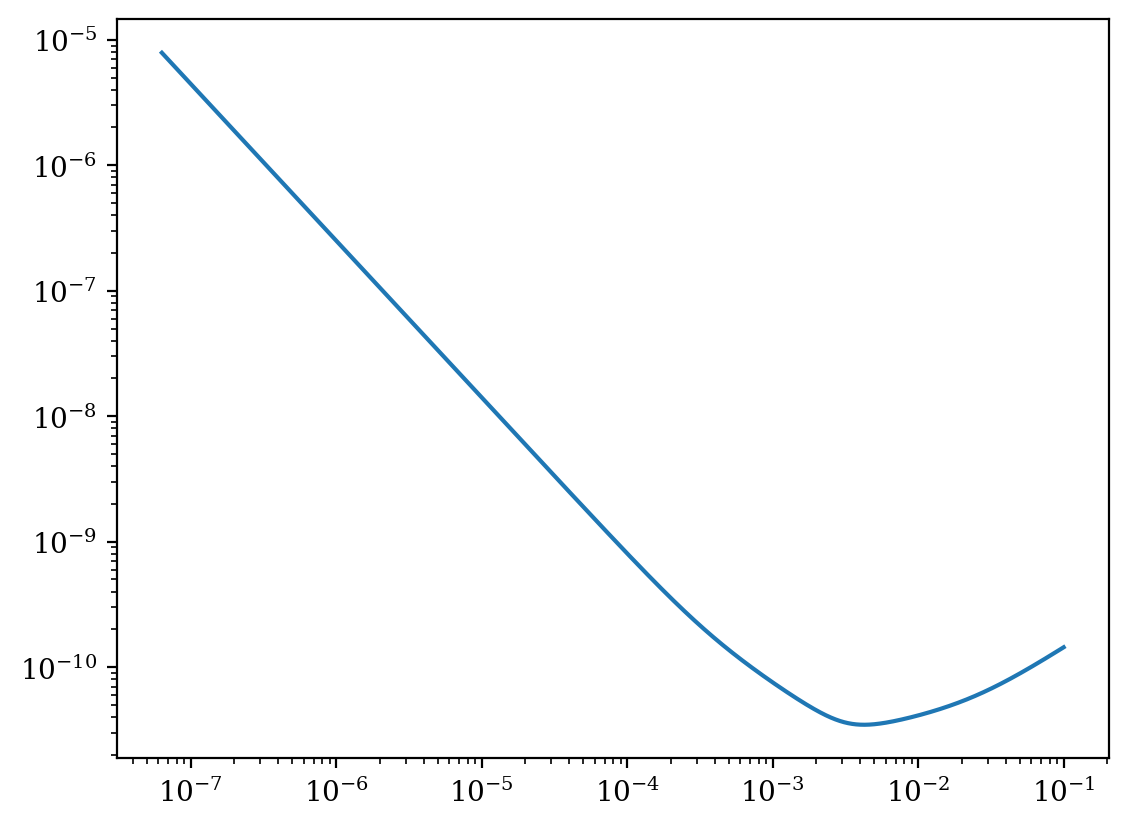

In [ ]:
from lisatools.sensitivity import LISASens, get_sensitivity, get_stock_sensitivity_options
sens_mat_characteristic_strain = get_sensitivity(freq , sens_fn='LISASens', return_type='char_strain', average = 'True')



plt.loglog(freq, np.sqrt(sens_mat_characteristic_strain))
plt.


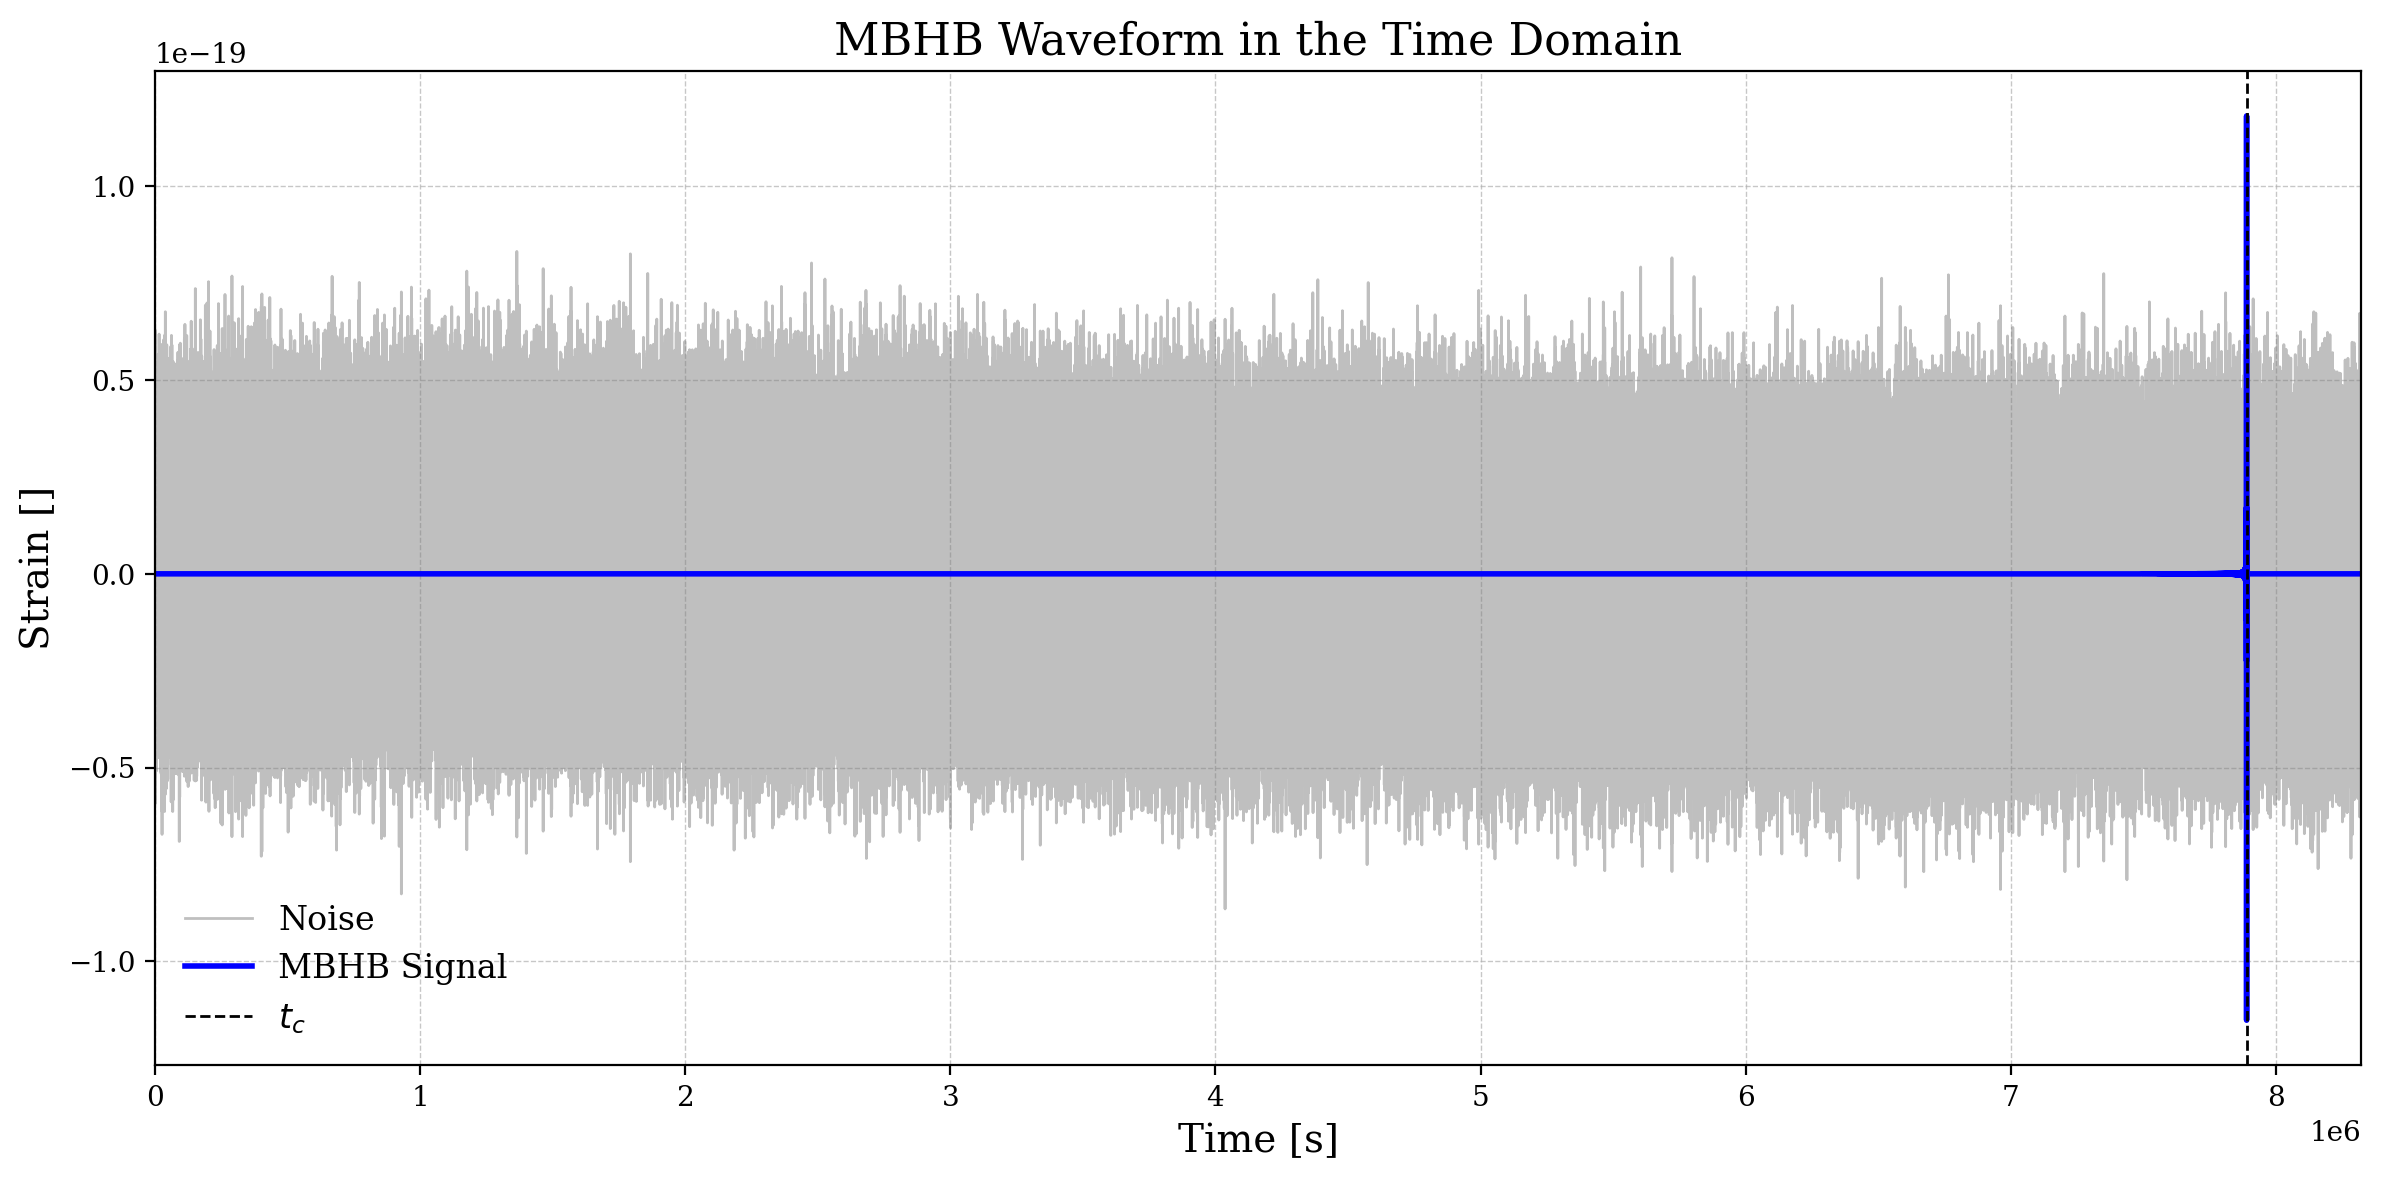

In [5]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(wave_time_domain[0])) * dt

plt.figure(figsize=(12, 6))

# Noise (muted, semi-transparent)
plt.plot(time, noises[1], label='Noise',
         color='gray', alpha=0.5, lw=1)

# Signal (bold, stands out)
plt.plot(time, wave_time_domain[0], label='MBHB Signal',
         color='blue', lw=2)

# Coalescence marker
plt.axvline(t_ref, color='k', ls='--', lw=1, label=r'$t_c$')

# Labels & limits
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Strain []', fontsize=14)
plt.title('MBHB Waveform in the Time Domain', fontsize=16)

plt.xlim(0, t_ref + 5*24*60*60)

# Grid & legend
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.legend(loc='lower left', fontsize=12, frameon=False)

plt.tight_layout()
#plt.savefig("thesis_figures/mbhb_waveform_time.pdf", bbox_inches="tight")
plt.show()


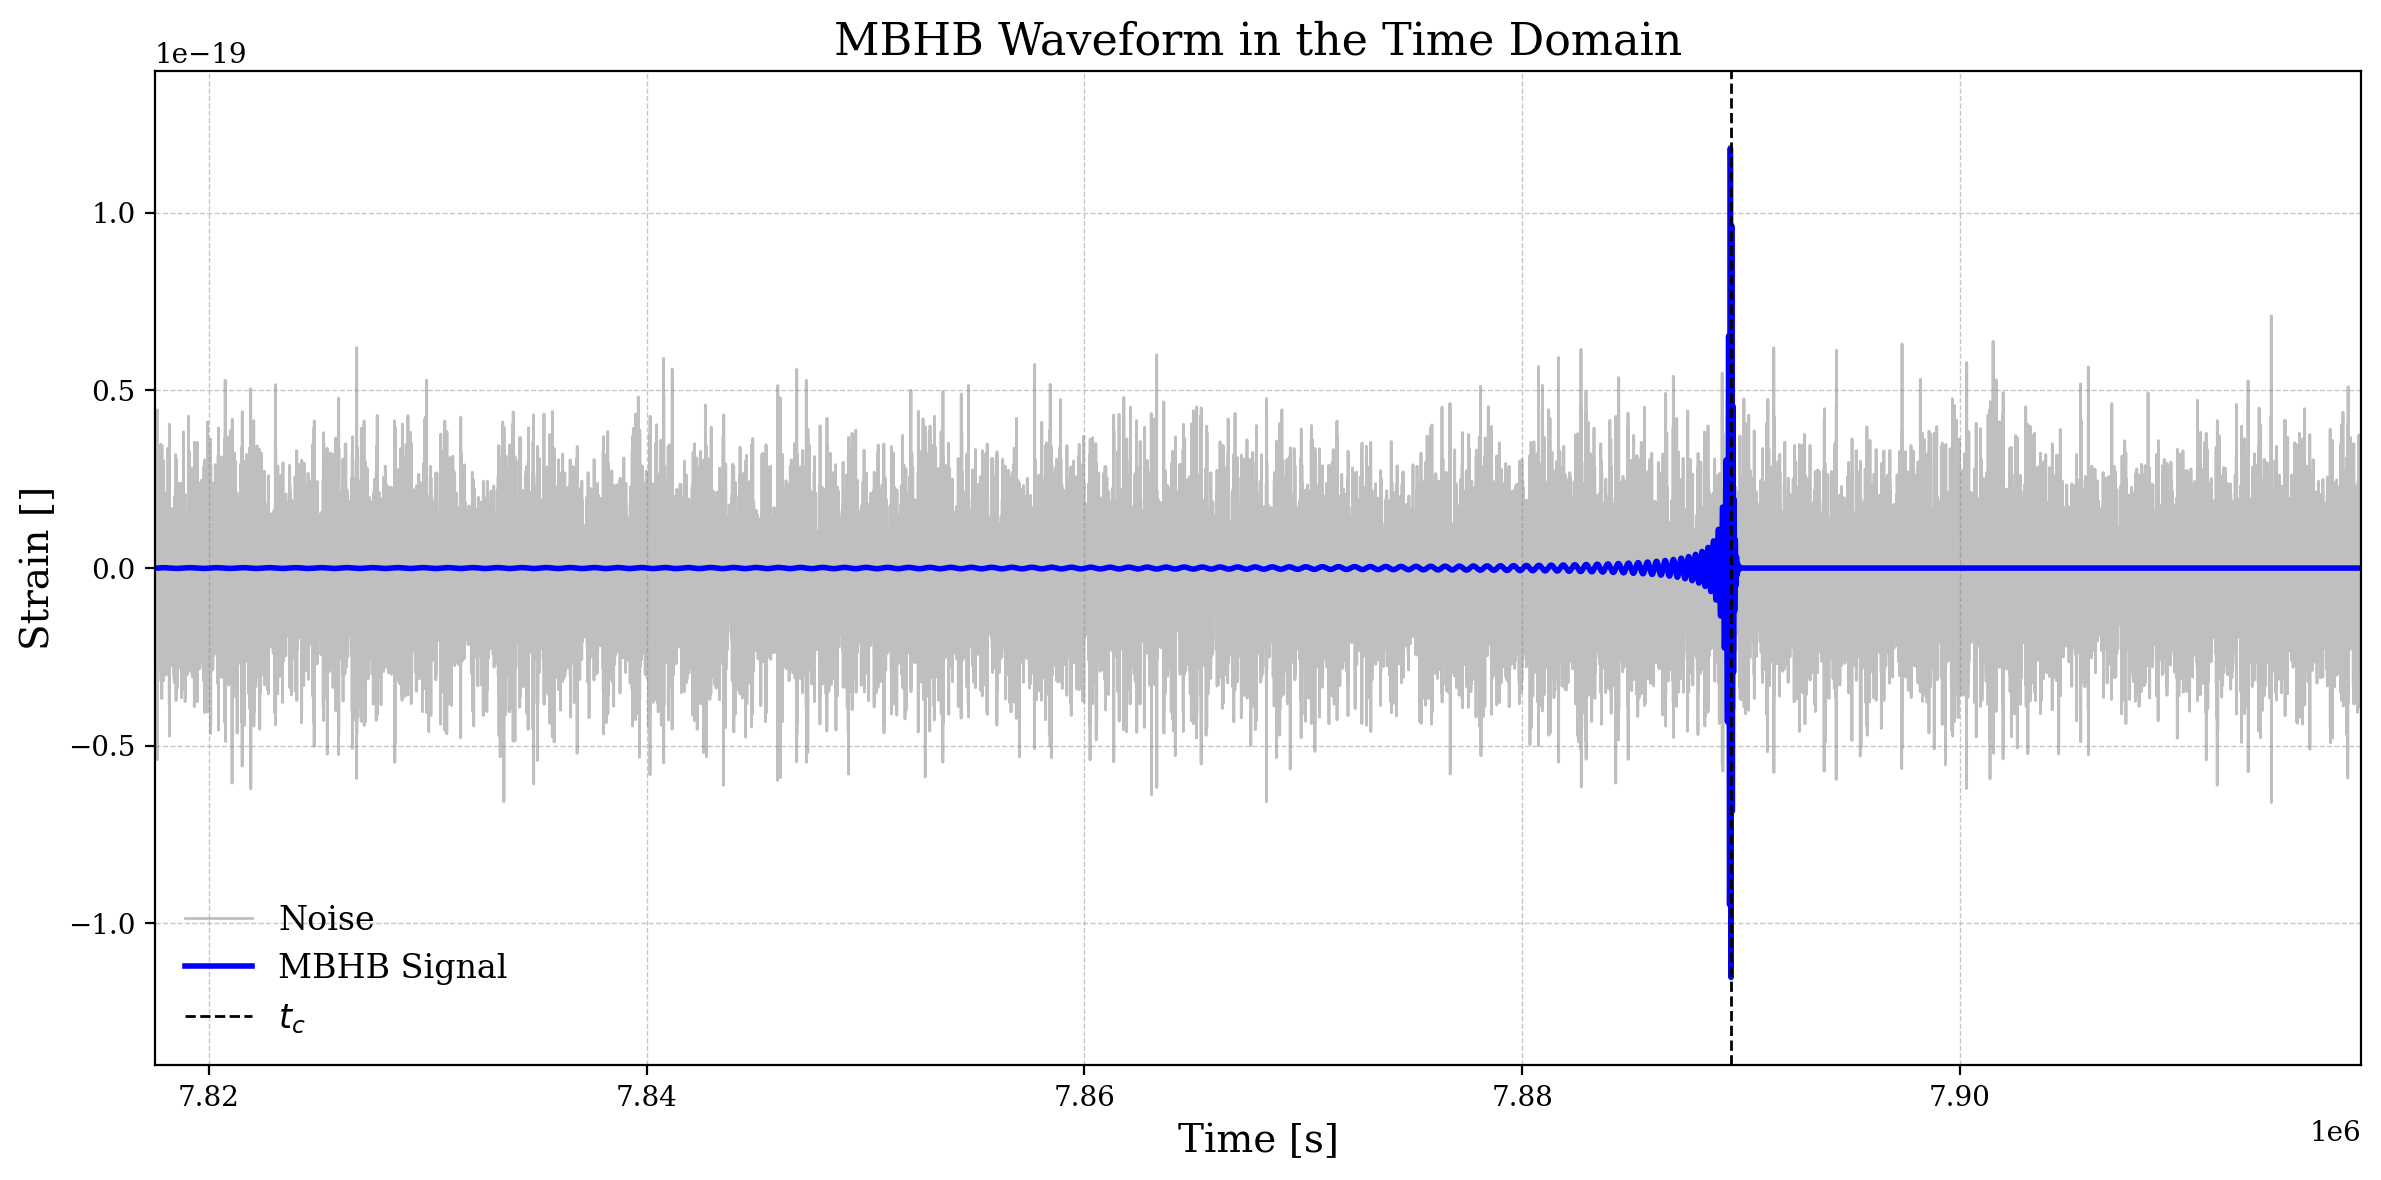

In [6]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(wave_time_domain[0])) * dt

plt.figure(figsize=(12, 6))

# Noise (muted, semi-transparent)
plt.plot(time, noises[1], label='Noise',
         color='gray', alpha=0.5, lw=1)

# Signal (bold, stands out)
plt.plot(time, wave_time_domain[0], label='MBHB Signal',
         color='blue', lw=2)

# Coalescence marker
plt.axvline(t_ref, color='k', ls='--', lw=1, label=r'$t_c$')

# Labels & limits
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Strain []', fontsize=14)
plt.title('MBHB Waveform in the Time Domain', fontsize=16)

plt.xlim(t_ref - 60*60*20, t_ref + 8*60*60)

# Grid & legend
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.legend(loc='lower left', fontsize=12, frameon=False)
plt.ylim(-1.4e-19, 1.4e-19)
plt.tight_layout()
plt.savefig("thesis_figures/mbhb_waveform_time.pdf", bbox_inches="tight")
plt.show()


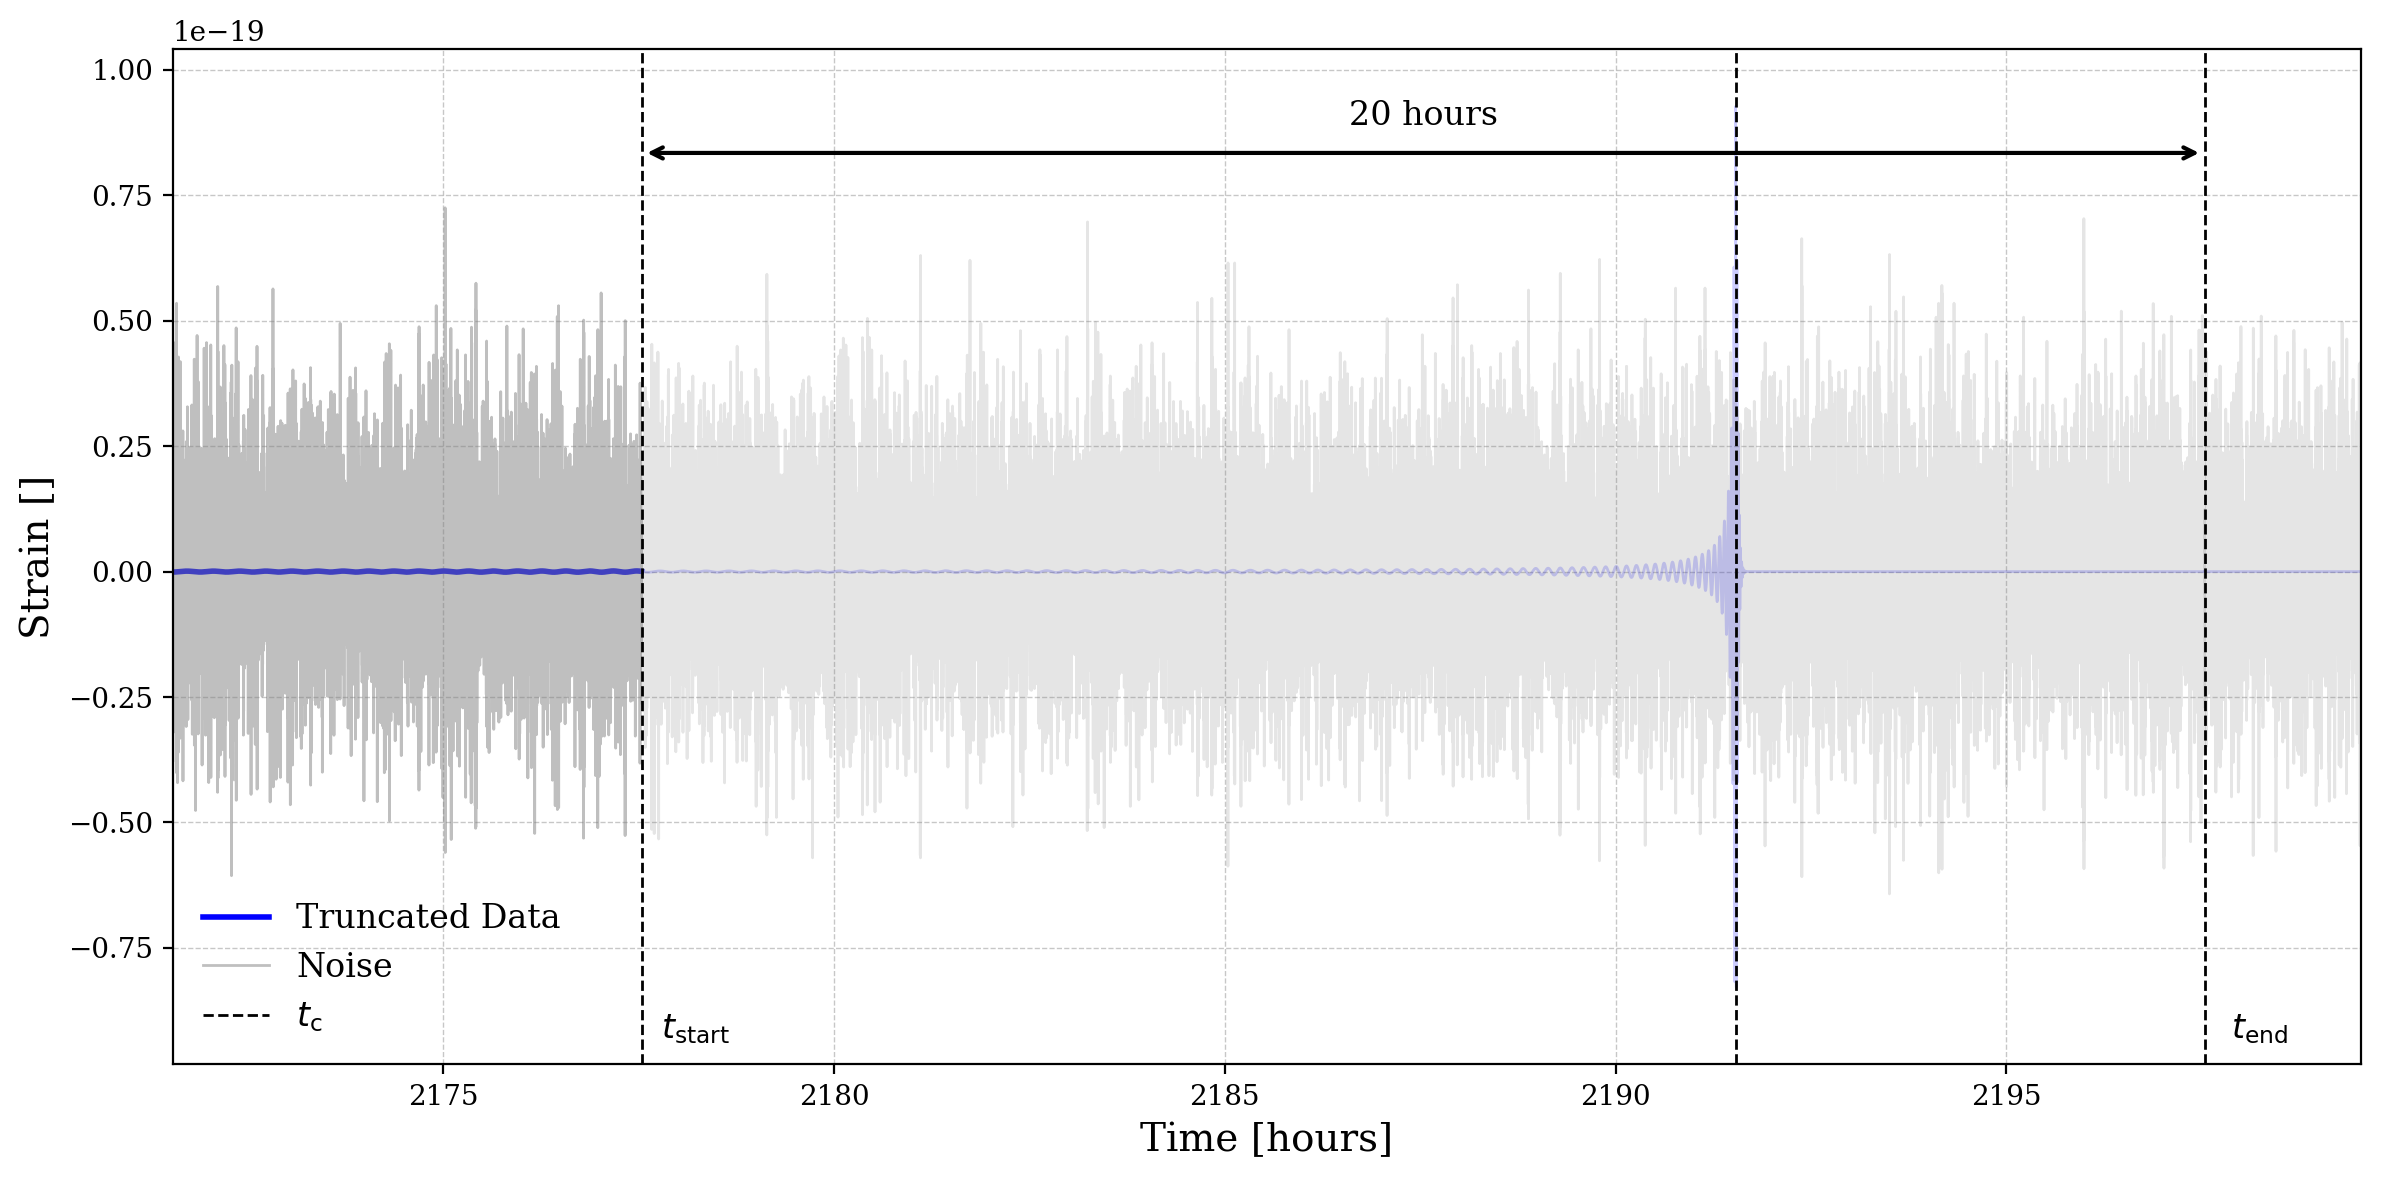

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# convert time to months
time = np.arange(len(wave_time_domain[0])) * dt
seconds_per_month = 1 * 3600  # 30 days in seconds
time_months = time / seconds_per_month

# Define your truncation boundaries
t_start = t_ref - 14*60*60  # 14 hours before merger
t_end   = t_ref + 6*60*60   # 6 hours after merger

# Convert to months
t_start_months = t_start / seconds_per_month
t_end_months   = t_end / seconds_per_month
t_ref_months   = t_ref / seconds_per_month

# Create masks for pre- and post-truncation regions
mask_before = time < t_start
mask_window = (time >= t_start) & (time <= t_end)
mask_after  = time > t_end

plt.figure(figsize=(12,6))

# Plot data before the window (faded)
plt.plot(time_months[mask_before], wave_time_domain[1][mask_before],
         color='blue', lw=2, label='Truncated Data')

# Plot data inside the 20-hour window (highlighted)
plt.plot(time_months[mask_window], wave_time_domain[1][mask_window],
         color='blue', alpha=0.2, lw=1.0)

# Optional: plot data after window (faded)
plt.plot(time_months[mask_after], wave_time_domain[1][mask_after],
         color='blue', alpha=0.2, lw=1.0)

# Noise in background
plt.plot(time_months[mask_before], noises[0][mask_before], color='gray', alpha=0.5, lw=1, label='Noise')
plt.plot(time_months[mask_window], noises[0][mask_window], color='gray', alpha=0.2, lw=1)
plt.plot(time_months[mask_after], noises[0][mask_after], color='gray', alpha=0.2, lw=1)

# Vertical lines
plt.axvline(t_start_months, color='k', ls='--', lw=1)
plt.axvline(t_end_months,   color='k', ls='--', lw=1)
plt.axvline(t_ref_months,   color='k', ls='--', lw=1, label=r'$t_{\text{c}}$')

# Labels at the bottom
y_text = min(wave_time_domain[1]) - 5e-21
x_text = 2500 / seconds_per_month  # adjust for months
plt.text(t_start_months+x_text, y_text, r'$t_{\rm start}$', ha='center', va='top', fontsize=12)
plt.text(t_end_months+x_text,   y_text, r'$t_{\rm end}$',   ha='center', va='top', fontsize=12)

# Horizontal arrow indicating the 20-hour window
y_arrow = max(wave_time_domain[1][mask_window])*0.9
plt.annotate(
    '', xy=(t_end_months, y_arrow), xytext=(t_start_months, y_arrow),
    arrowprops=dict(arrowstyle='<->', color='k', lw=1.5)
)
plt.text((t_start_months+t_end_months)/2, y_arrow*1.05, '20 hours', ha='center', va='bottom', fontsize=12)

# Labels, title, grid
plt.xlabel('Time [hours]', fontsize=14)
plt.ylabel('Strain []', fontsize=14)
#plt.title('Time-Domain Pre-Merger Signal', fontsize=16)
plt.grid(True, ls='--', lw=0.5, alpha=0.7)

# Legend
plt.legend(loc='lower left', fontsize=12, frameon=False)
plt.xlim((t_ref - 60*60*20)/seconds_per_month, (t_ref + 8*60*60)/seconds_per_month)
plt.tight_layout()
plt.savefig("thesis_figures/truncated_waveform_time.pdf", bbox_inches="tight")

plt.show()


In [8]:
wave_time_domain_with_noise[0]
np.where(wave_time_domain_with_noise[0] == max(wave_time_domain_with_noise[0])), wave_time_domain_with_noise[0].shape

((array([1577903]),), (3155814,))

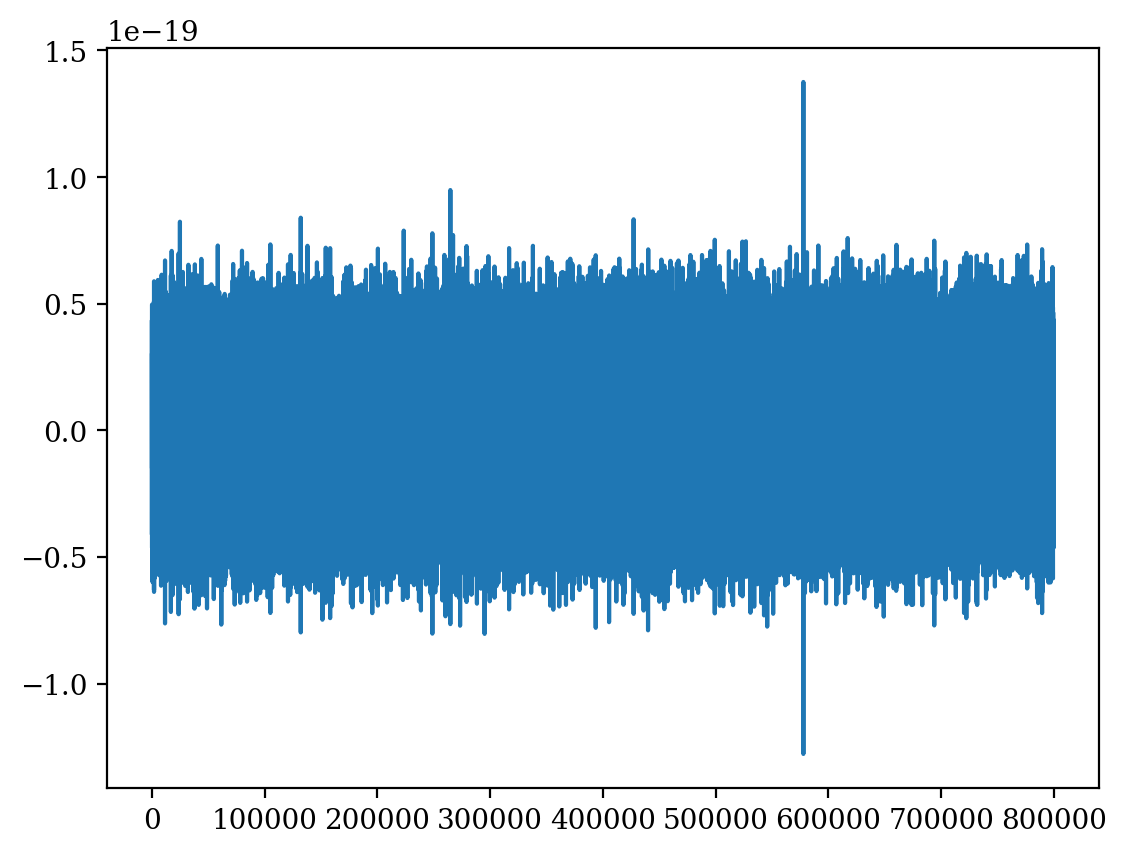

In [9]:
truncated_wave_for_plot = wave_time_domain_with_noise[0][1000000:1800000]
plt.plot(truncated_wave_for_plot)

In [17]:
def generate_noise(N, dt, sens_mat, seed=None):
    if seed is not None:
        np.random.seed(seed)
    noises = []
    for sens_fn in sens_mat.sens_mat:
        noise = np.fft.irfft(np.random.normal(0.0, np.sqrt(sens_fn))
                             +1j * np.random.normal(0.0, np.sqrt(sens_fn))
                            ) /np.sqrt(dt*4/N)
        noises.append(noise)
    noises = np.array(noises)
    return noises

DAY_SI = 24*3600
Tobs = YRSID_SI + 5*DAY_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1]

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 1e5
m2 = 1e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 1.0
inc = 2*np.pi/3.
beta= 0
lam = 0
psi = np.pi
t_ref = Tobs - 60*60*24 - 5*DAY_SI

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)
noises = generate_noise(N, dt, AET1SensitivityMatrix(freq), seed=0)
wave_time_domain_with_noise = wave_time_domain + noises

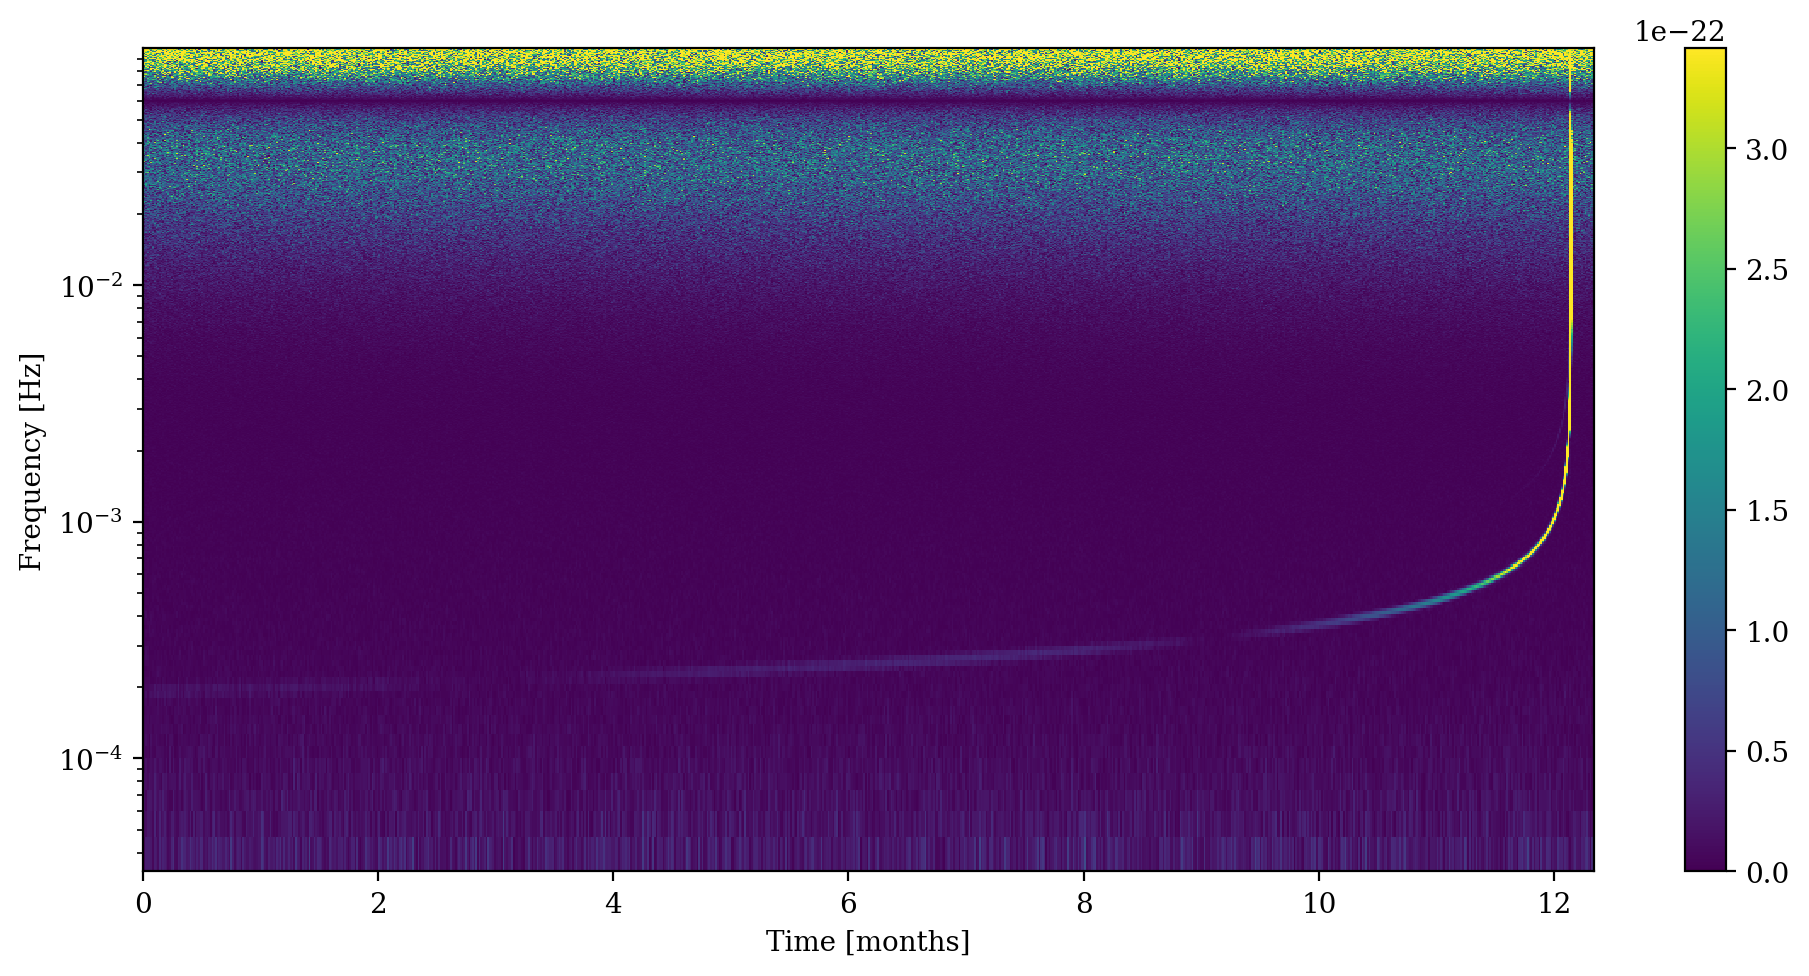

In [ ]:
f, t, Zxx = sp.signal.stft(wave_time_domain_with_noise[1], fs=1/dt, nperseg=15000,)
max_freq = 0.1
max_freq_idx = np.searchsorted(f, max_freq)
min_freq = 3e-5  #3e-5
min_freq_idx = np.searchsorted(f, min_freq)

# Convert t to months before plotting
t_months = t / (30 * 24 * 3600)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_months, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0, 
               vmax= np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/20,
               rasterized=True,
)
plt.yscale('log')
plt.xlim(t_months[0], t_months[-2])
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [months]')
plt.colorbar()
plt.tight_layout()
plt.savefig("thesis_figures/sftf_modulation_1e-5.pdf")
plt.show()

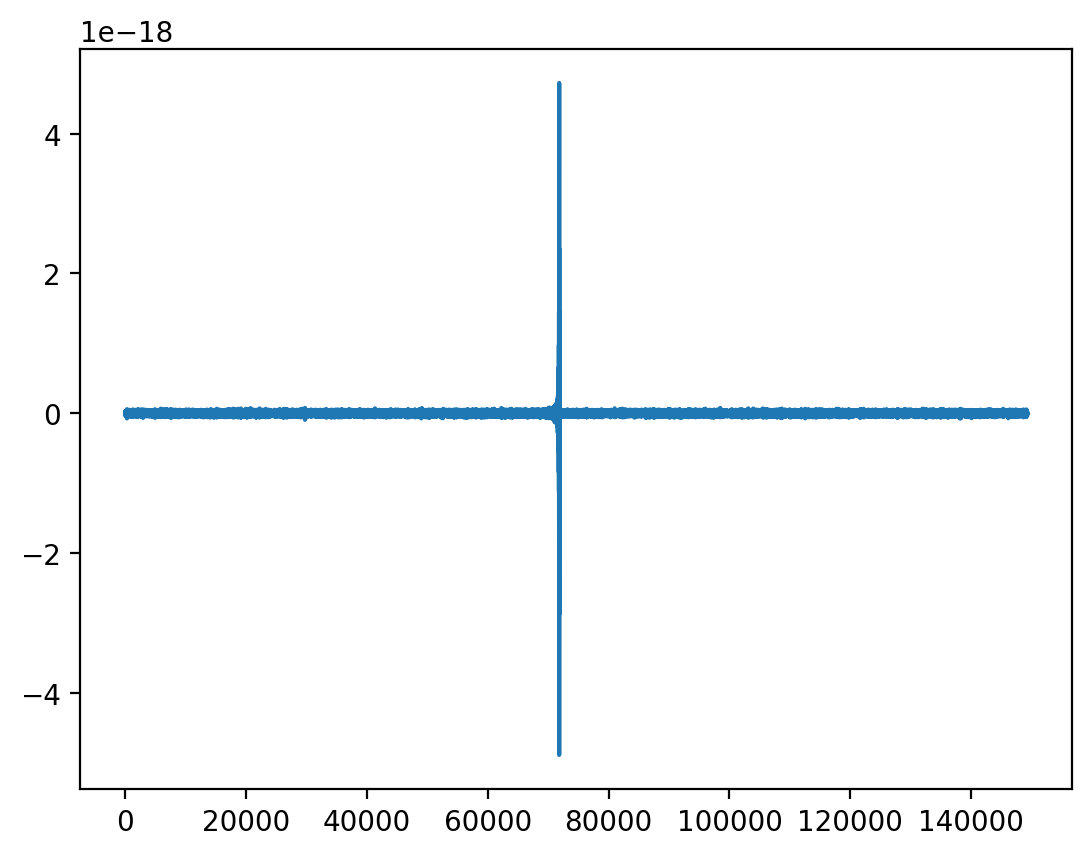

In [76]:
def post_observation(gravitational_wave_data_t, t_array, cutoff_index):
        data_t_post_observation = gravitational_wave_data_t[:, cutoff_index:]
        t_array_post_observation = t_array[cutoff_index:]

        return data_t_post_observation, t_array_post_observation

data_t_post_observation, t_array_post_observation =  post_observation(data_t, t_array, cutoff_index)
plt.plot(data_t_post_observation[0])

(151,) (501,)


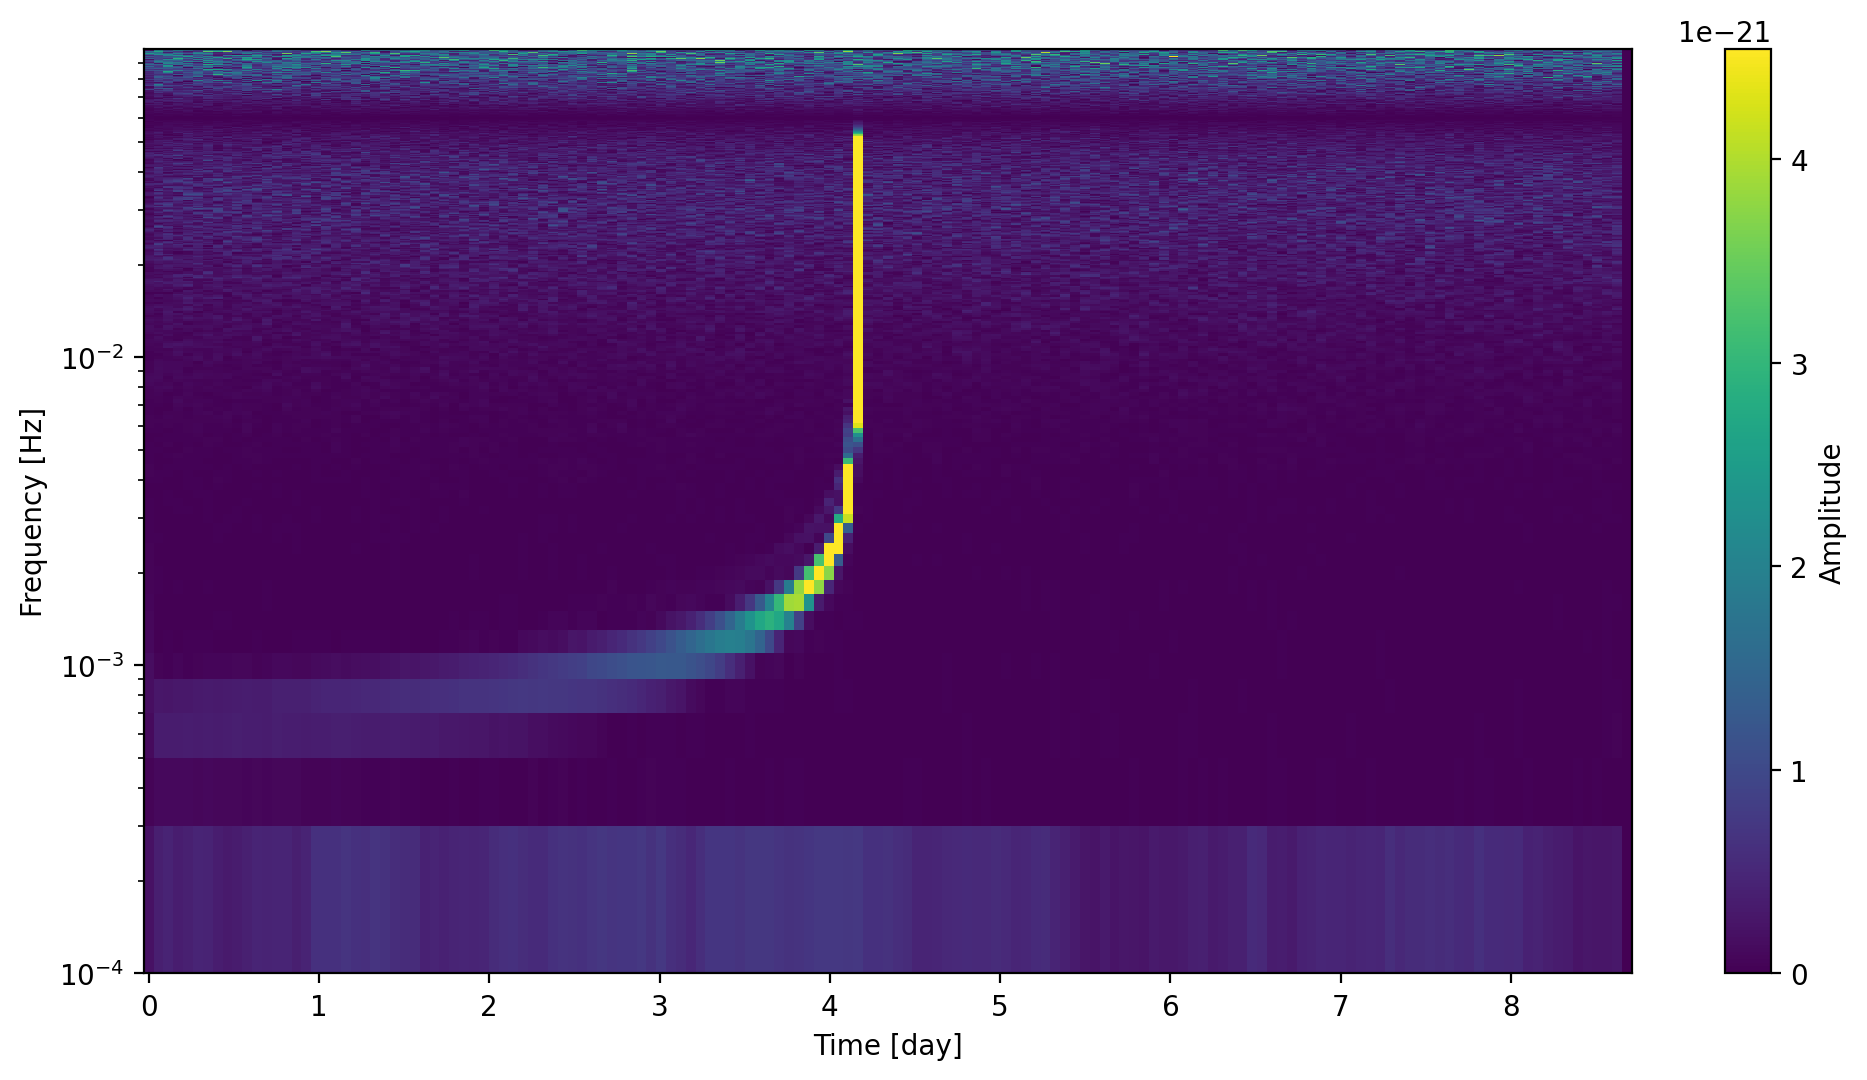

In [77]:
f, t, Zxx = sp.signal.stft(data_t_post_observation[0], fs=1/sim.dt, nperseg=1000, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 1e-1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t/(3600*24), f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [day]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
cbar = plt.colorbar()
cbar.set_label("Amplitude") 


# Spectrogram

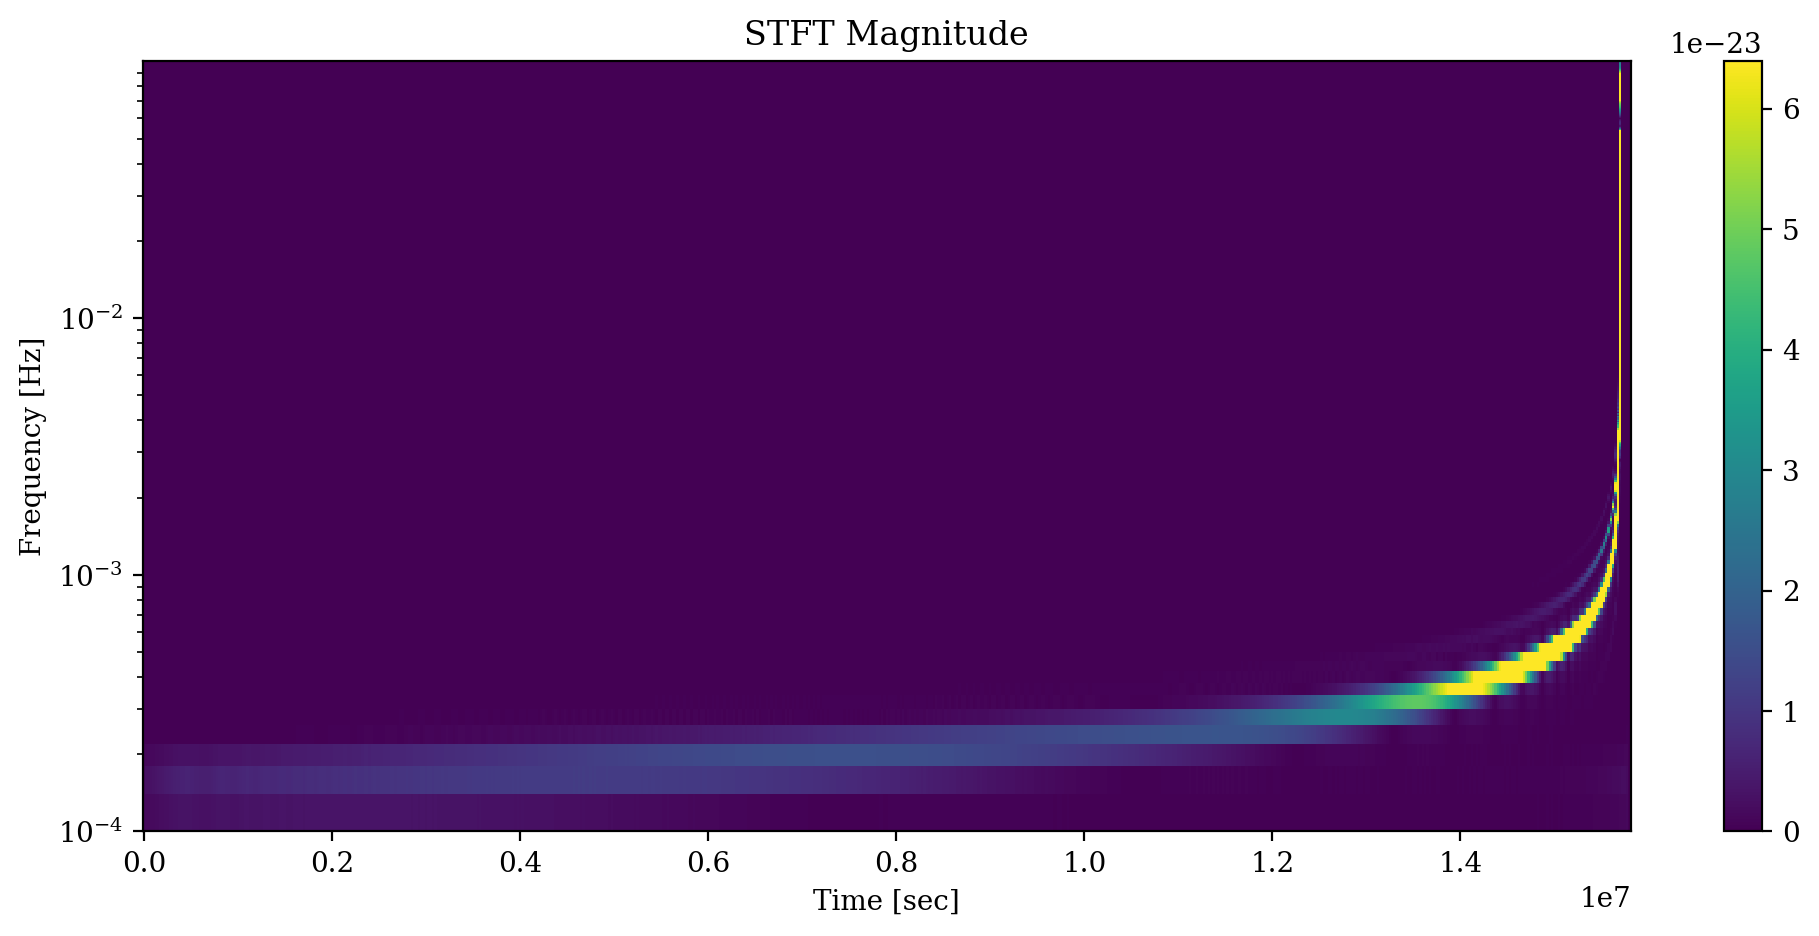

In [15]:
Tobs = 6*YRSID_SI/12
dt = 5.
include_T_channel = False # Set to True if you want to include the T channel in the simulation, otherwise only A and E channels will be included.

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)

sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

f, t, Zxx = sp.signal.stft(sim.signal_t[0,0], fs=1/sim.dt, nperseg=5000, noverlap=0)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/100)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

(7501,) (419,) 3142919


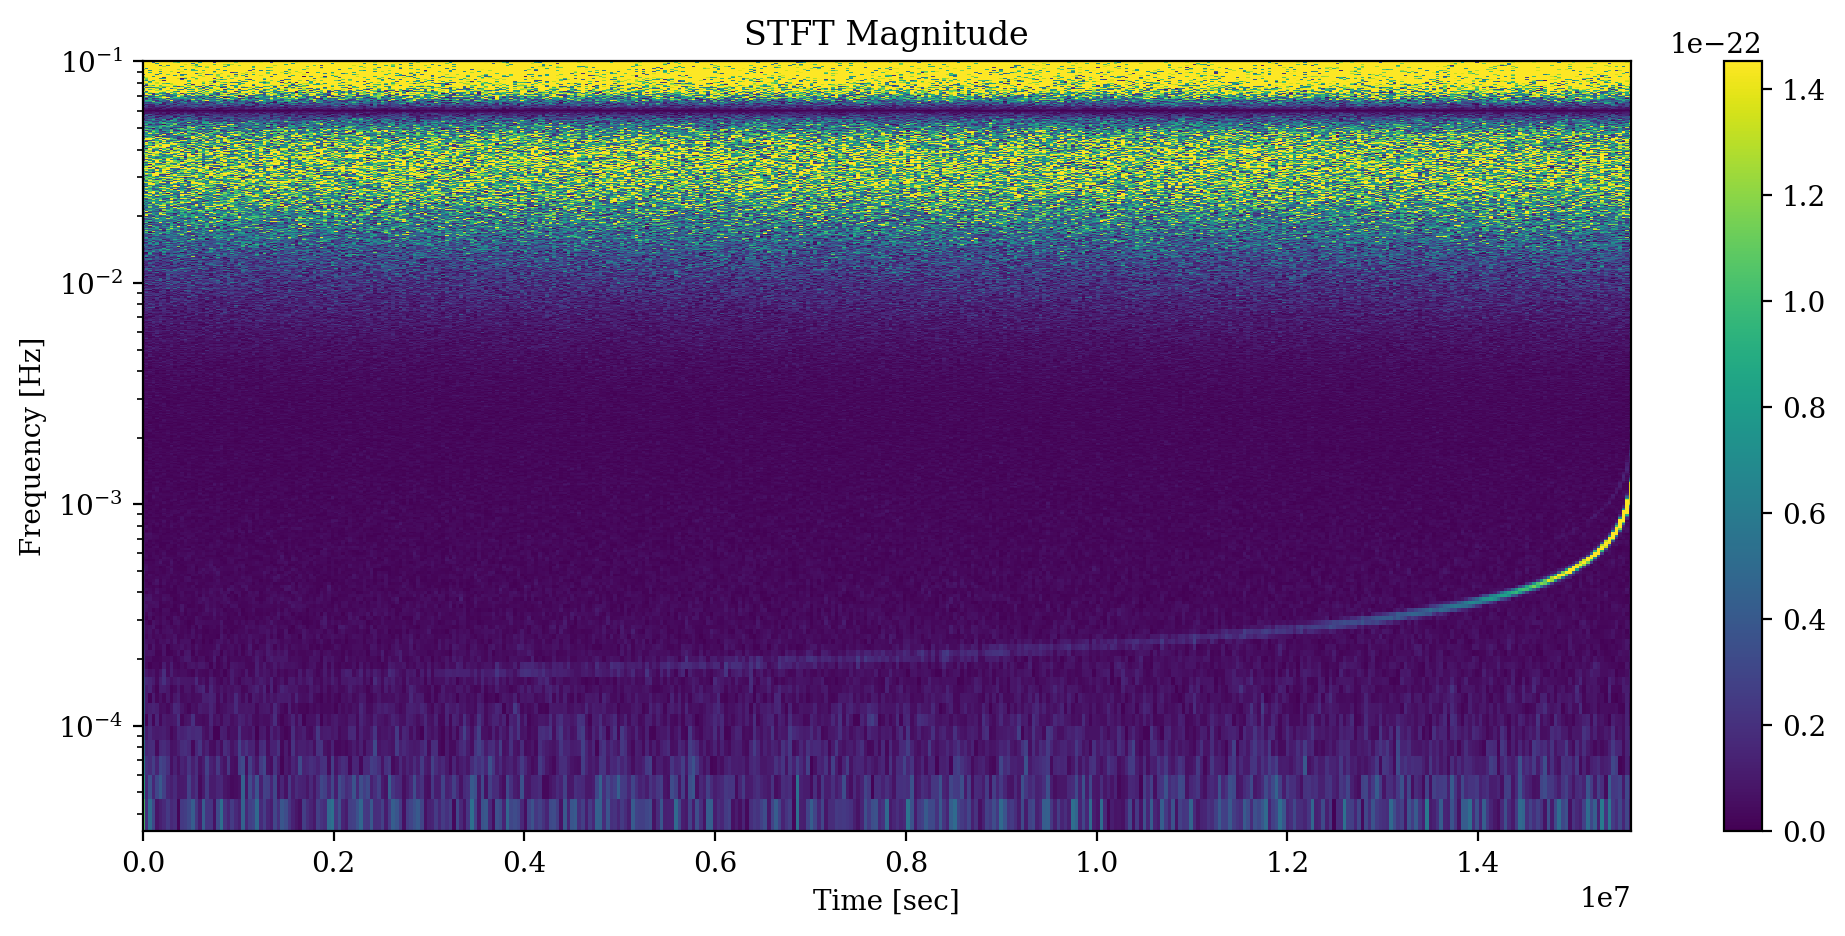

In [45]:
# Not doing the premerger now to see if the code works better with the merger included
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60

def pre_merger(gravitational_wave_data_t, time_before_merger, t_ref, t_array):
        cutoff_time = t_ref - time_before_merger
        cutoff_index = np.searchsorted(t_array, cutoff_time)
        data_t_truncated = gravitational_wave_data_t[:, :cutoff_index]
        return data_t_truncated, cutoff_index

data_t_truncated,   cutoff_index =  pre_merger(data_t, time_before_merger, t_ref, t_array)
signal_t_truncated, cutoff_index =  pre_merger(sim.signal_t[0], time_before_merger, t_ref, t_array)

f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=15001, )

print(f.shape, t.shape, f.shape[0]*t.shape[0])

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 3e-5)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.xlim(0, t[-3])
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()

# 14 hours before merger

# Presentation Plots

In [1]:
from tools.likelihood import TimeFreqSNR
analysis = TimeFreqSNR(
    data_t=data_t_truncated,
    wave_gen=wave_gen,
    nperseg=1414,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=True
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters, waveform_kwargs=waveform_kwargs)
new_distance = dist /  amplitude
print((new_distance - dist)/(PC_SI*1e9) , (new_distance-dist)/dist)
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = ",  SNR)

NameError: name 'data_t_truncated' is not defined

In [ ]:
f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=2081, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

In [ ]:
max_index = np.argmax(wave_full)
print("Index of max value in wave_truc:", max_index)

In [ ]:
wave_full = sim.signal_t[0,0]
max_index = np.argmax(wave_full)
delta_left = 2000
delta_right = 1500
wave_truc = wave_full[max_index-delta_left:max_index+delta_right]
split_index = 800
wave_truc_part_1 = wave_truc.copy()
wave_truc_part_1[split_index:] = np.nan
wave_truc_part_2 = wave_truc.copy()
wave_truc_part_2[:split_index] = np.nan
tarray_truncated = np.arange(len(wave_truc)) 
max_index_truc = np.argmax(wave_truc)
delta_trunc = 800
plt.figure(figsize=(12, 5))
plt.plot(tarray_truncated, wave_truc_part_1, color='black', alpha=0.5)
plt.plot(tarray_truncated, wave_truc_part_2, color='black', alpha=1)
plt.xlim(0, len(wave_truc))
plt.axvline(max_index_truc-delta_trunc)
plt.axvline(max_index_truc+delta_trunc)

CHARACTERISTIC STRAIN

In [ ]:
# imports 
from lisatools.sensitivity import get_sensitivity
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase

wave_gen = PhenomHMAmpPhase()

# PhenomHMAmpPhase by itself generates PhenomHM waveforms in the amplitude and phase representation WITHOUT LISA RESPONSE!
# LISA reponse = AET channels =  what we see in the detector. This is what we care about. This is added in BBHWaveformFD
# BBHWaveformFD also uses PhenomHMAmpPhase to generate the waveforms, but it also adds the LISA response.

m1 = 3e6
m2 = 1.5e6
chi1 = 0.2
chi2 = 0.4
dist = 15 * 1e9 * PC_SI
f_ref = 0.0 # Hz            # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0               # phase at f_ref
t_ref = .5*YRSID_SI # seconds
length = 1024               # THIS WAS SO CONFUSING BECAUSE I DIDN'T READ THE DOCUMENTATION PROPERLY (See comments in the BBHWaveformFD cell)

wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)



/var/folders/zq/6x2qbk397t13zwgl047mwbkm0000gn/T/ipykernel_95172/2665167575.py:7: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.loglog(wave_gen.freqs_shaped[0, i], char_strain, label=mode)


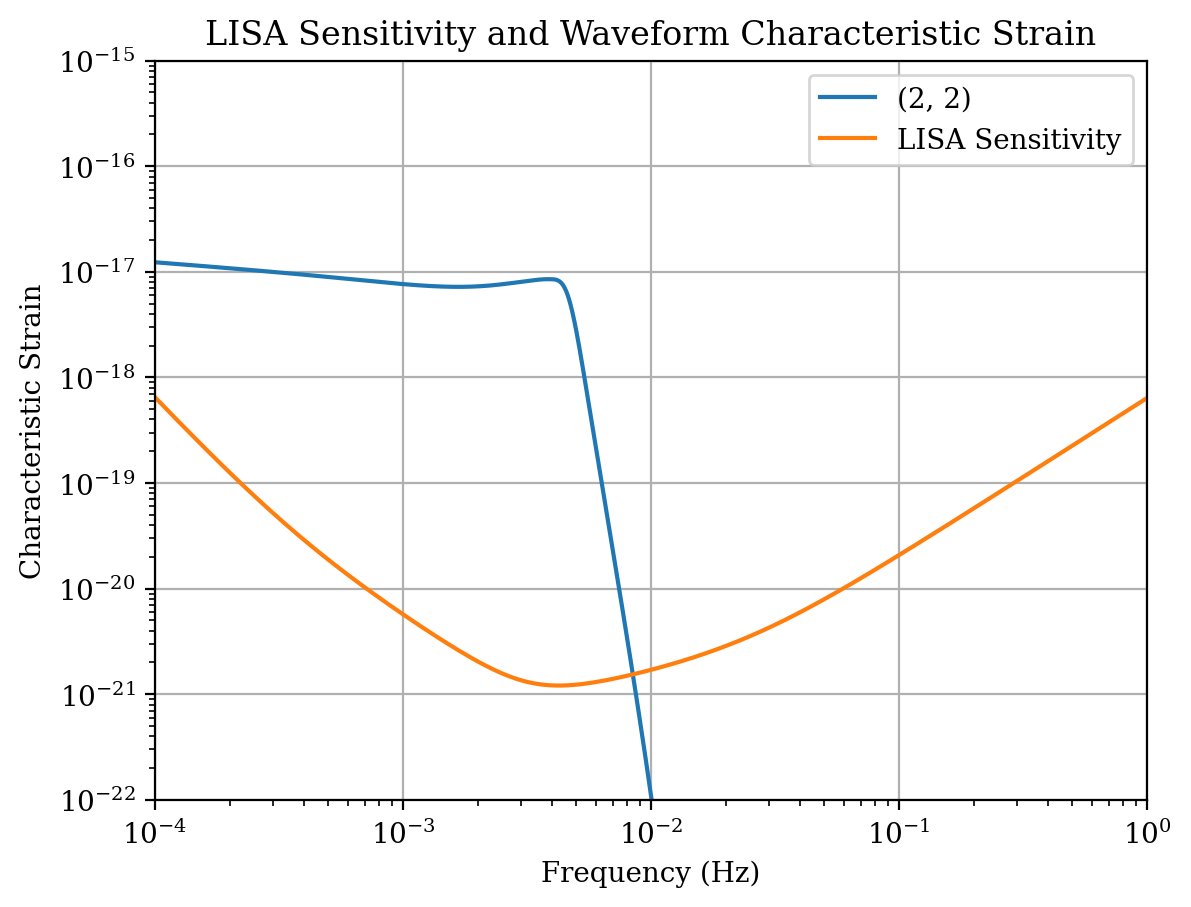

In [43]:
fn = np.logspace(-4, 1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 

modes = [(2,2)]
for i, mode in enumerate(modes):
    char_strain = wave_gen.freqs_shaped[0, i] * wave_gen.amp[0, i]
    plt.loglog(wave_gen.freqs_shaped[0, i], char_strain, label=mode)

plt.loglog(fn, Sn_char_strain, label="LISA Sensitivity")

plt.title("LISA Sensitivity and Waveform Characteristic Strain")
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic Strain")
plt.ylim(1e-22, 1e-15)
plt.xlim(1e-4, 1e0)
plt.grid()